# 04 - Diabetes usando `src/`

Misma exploración del notebook 03 pero apoyándonos en las funciones del paquete `estadistica`.

- La carga del archivo (URL, separador, ruta local) deja de ser problema del notebook → la maneja `estadistica.data.load_diabetes()`.
- El reporte de nulos genérico vive en `estadistica.transforms.reporte_nulos()` — el mismo que usamos para Titanic.
- El notebook queda enfocado en la **narrativa del análisis**, no en boilerplate.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import seaborn as sns

from estadistica import load_diabetes
from estadistica.transforms import reporte_nulos

sns.set_theme(style="whitegrid")

## Cargar el dataset

Una línea. La función decide local vs URL automáticamente.

In [2]:
df = load_diabetes()
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (442, 11)


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


## Chequeo rápido de calidad

Mismo `reporte_nulos` que usamos en Titanic — esa es la idea de tener funciones genéricas en `src/`.

In [3]:
reporte_nulos(df)

,nulos,pct,dtype
AGE,0,0.0,int64
SEX,0,0.0,int64
BMI,0,0.0,float64
BP,0,0.0,float64
S1,0,0.0,int64
S2,0,0.0,float64
S3,0,0.0,float64
S4,0,0.0,float64
S5,0,0.0,float64
S6,0,0.0,int64


## Análisis

A partir de acá el notebook se concentra solo en lo específico de este dataset: distribución del target, correlaciones con `Y`, matriz de correlación entre predictores.

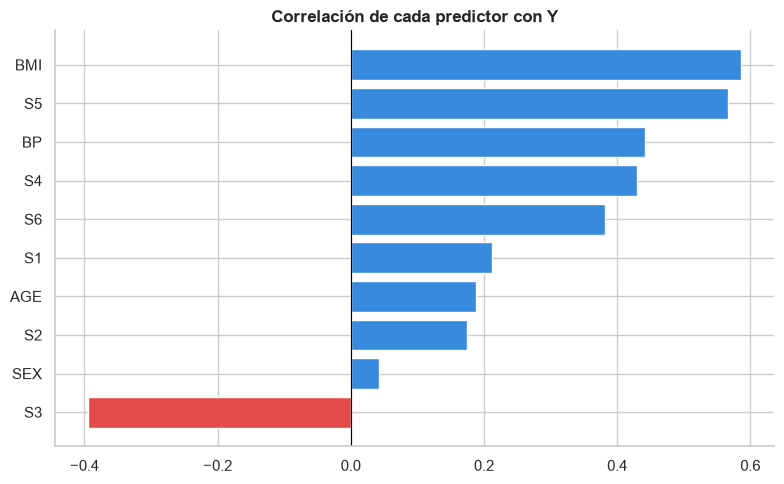

In [4]:
predictores = [c for c in df.columns if c != "Y"]

corr_con_y = df.corr(numeric_only=True)["Y"].drop("Y").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colores = ["#E24B4A" if v < 0 else "#378ADD" for v in corr_con_y.values]
ax.barh(corr_con_y.index, corr_con_y.values, color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada predictor con Y", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Guardar para el siguiente paso

Para este dataset no hay limpieza que hacer, pero igual ilustramos el patrón de guardar en `data/processed/` para el próximo notebook (modelado).

In [5]:
from estadistica.paths import PROCESSED_DIR

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
salida = PROCESSED_DIR / "diabetes.csv"
df.to_csv(salida, index=False)
print(f"Guardado en: {salida}")

Guardado en: /Users/noovou/dev/fup/estadistica/data/processed/diabetes.csv


## Comparación con el notebook 03

| | Notebook 03 (tradicional) | Notebook 04 (con `src/`) |
|---|---|---|
| Carga de datos | 3 líneas + recordar `sep="\t"` | `load_diabetes()` |
| Si cambia la URL | Editar todos los notebooks | Editar solo `src/estadistica/data.py` |
| Lógica reusable | Copiar/pegar entre notebooks | Importar desde `estadistica` |
| Testeable | No | Sí (podés testear `load_diabetes` con pytest) |

**Regla:** el notebook 03 es perfecto cuando estás explorando algo nuevo. Cuando una pieza se vuelve estable y la vas a usar de nuevo, la promovés a `src/` — y el notebook 04 es lo que queda.